# Validation

## 0. Merging the dataset

In [10]:
def load_jsonl_as_dict(path, key):
    with open(path, "r", encoding="utf-8") as f:
        return {json.loads(line)[key]: json.loads(line) for line in f}

scores = load_jsonl("scores.jsonl")
articles = load_jsonl_as_dict("data/articles.jsonl", "article_id")
summaries = load_jsonl_as_dict("data/summaries.jsonl", "article_id")

# Merge
merged = []
for s in scores:
    aid = s["article_id"]
    
    article = articles.get(aid, {})
    summary = summaries.get(aid, {})
    
    merged.append({
        **s,
        "article": article.get("text", ""),
        "summary": summary.get("summary", "")
    })

Quick check

In [13]:
merged[2]

{'summary_id': '34991666_c1f887ae',
 'article_id': '34991666',
 'relevance': 0.9877426624298096,
 'hallucination': 9.230769082435585e-09,
 'salience': 0.25,
 'compression_ratio': 0.16612903199011447,
 'compression_score': 0.5,
 'truncation': 1.0,
 'noise': False,
 'global_score': 0.6981613965952407,
 'label': 'good',
 'article': '乱射事件現場の警察特殊部隊 調べによると、銃撃犯たちは戦闘服のような服装で施設に乱入し、銃を乱射したのち黒いSUV（多目的スポーツ車）で逃走。事件発生から約4時間後、市内の住宅地で窓を撃ち抜かれた黒いSUVを警官隊が包囲した。このSUVと乱射事件の関連について警察は明らかにしていないが、現場で1人が射殺されたという。 米連邦捜査局（FBI）はテロ攻撃かまだ不明としているが、地元警察は国内テロの可能性があるとみている。 BBCのジェイムズ・クック記者は現場から、「つまりパリ連続襲撃のあとだけに、これがイスラム過激主義のテロだと示す直接証拠はないという意味だと思う」と解説。「むしろ、もしこれがテロ攻撃なら、米国内の独自のテロ攻撃かもしれないということだ」。 現場のインランド地域センターは、自閉症などで精神医療を必要とする大人を支援する医療施設。建物から避難する人の中には、医師や警官に付き添われストレッチャーで搬送される人もいた。 現場にいた大勢は用意されたバスで避難。周辺の建物で働く人たちは建物内に残り鍵をかけて待機しているという。 マルコス・アギレラさんの妻は事件発生当時、建物内にいたという。アギレラさんはABCニュースに「みんな妻のオフィスに隠れドアに鍵をかけたが、撃たれた人が倒れているのを見たそうだ」と話した。アギレラさんの妻は無事に脱出したという。 福祉センターで働く娘が建物内に隠れているというテリー・ペティットさんは報道陣に、「何人か撃たれた。オフィスでおまわりさんを待ってる。祈って。オフィスにたてこもってる

## 1. Manual inspection

Let's observe 5 high scores and 5 low score. Of course, we will translate if as before:

In [17]:
from translatepy import Translator
import json

# ----------------------------
# Sort by global score
# ----------------------------
sorted_data = sorted(merged, key=lambda x: x["global_score"], reverse=True)

top_5 = sorted_data[:5]
bottom_5 = sorted_data[-5:]

translator = Translator()

# ----------------------------
# Helper print function
# ----------------------------
def show_examples(examples, title):
    print("\n" + "="*50)
    print(title)
    print("="*50)

    for i, ex in enumerate(examples):
        print(f"\n--- Example {i+1} ---")
        print(f"Summary ID: {ex['summary_id']}")
        print(f"Global score: {ex['global_score']:.3f}")
        print(f"Label: {ex['label']}")

        article_fr = translator.translate(ex["article"], "French")
        summary_fr = translator.translate(ex["summary"], "French")
        print("\nOriginal:")
        print(ex["summary"])

        print("\nArticle (FR):")
        print(article_fr)
        
        print("\nSummary (FR):")
        print(summary_fr)

# ----------------------------
# Display
# ----------------------------
show_examples(top_5, "TOP 5 HIGHEST SCORES")
show_examples(bottom_5, "BOTTOM 5 LOWEST SCORES")


TOP 5 HIGHEST SCORES

--- Example 1 ---
Summary ID: 45715110_979831e4
Global score: 0.735
Label: good

Original:
人体の免疫システムを使ってがんと戦う手法を発見した科学者2人が、今年のノーベル医学生理学賞を受賞した。

Article (FR):
Michelle Roberts, rédactrice en chef de BBC News Online Health Les recherches menées par le professeur James P. Allison, 70 ans, de l'Université du Texas aux États-Unis, et le professeur émérite Tasuku Honjo, 76 ans, de l'Université de Kyoto au Japon, ont contribué au traitement du cancer de la peau avancé et mortel.L'Académie suédoise, qui organise la remise du prix Nobel, a déclaré que la thérapie par inhibition des points de contrôle immunitaire avait révolutionné le traitement du cancer.Plusieurs experts affirment que le traitement s’est avéré « extrêmement efficace ».Alison et Honjo se partageront le prix de 9 millions de couronnes suédoises (environ 115 millions de yens).Après avoir reçu le prix, Honjo a déclaré aux journalistes : « J'aimerais poursuivre un peu plus mes recherches afin de pouvoir sauve

This seems good for both the highest scores and lowest scores.

## 2. Sanity checks

=== BASIC INFO ===
(250, 13)
Index(['summary_id', 'article_id', 'relevance', 'hallucination', 'salience',
       'compression_ratio', 'compression_score', 'truncation', 'noise',
       'global_score', 'label', 'article', 'summary'],
      dtype='object')



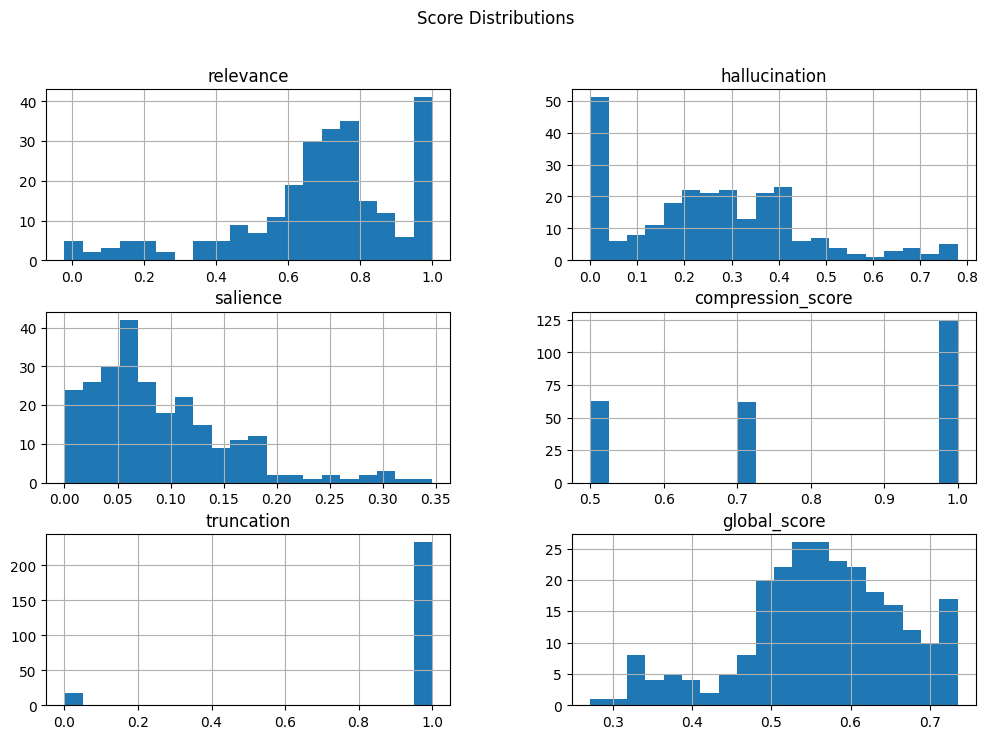

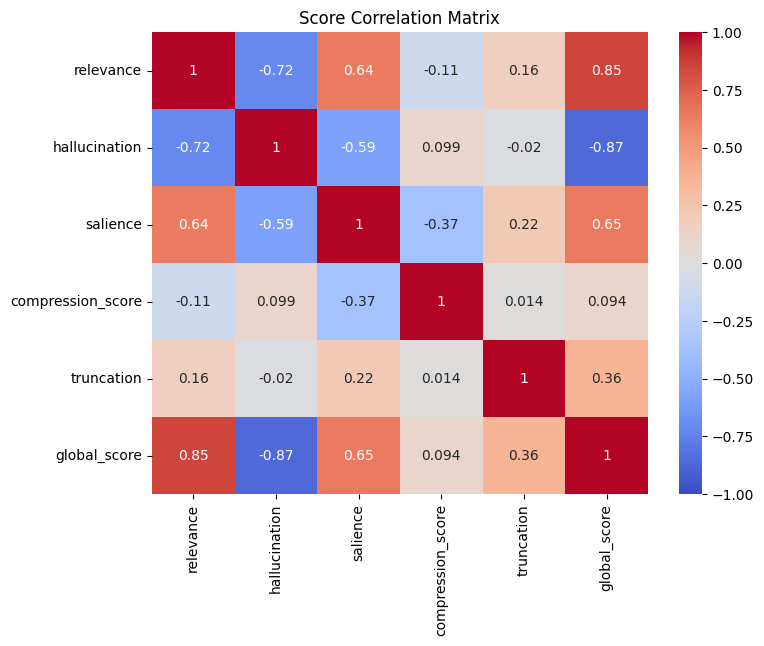


=== CORRELATIONS WITH GLOBAL SCORE ===
global_score         1.000000
relevance            0.850297
salience             0.645027
truncation           0.357278
compression_score    0.094281
hallucination       -0.867140
Name: global_score, dtype: float64

=== EXPECTED BEHAVIOR CHECK ===
Hallucination vs Global (should be NEGATIVE): -0.867139972878724
Relevance vs Global (should be POSITIVE): 0.8502973721326548
Salience vs Global (should be POSITIVE): 0.6450269841151628

=== LABEL DISTRIBUTION ===
label
medium    137
good       91
poor       22
Name: count, dtype: int64


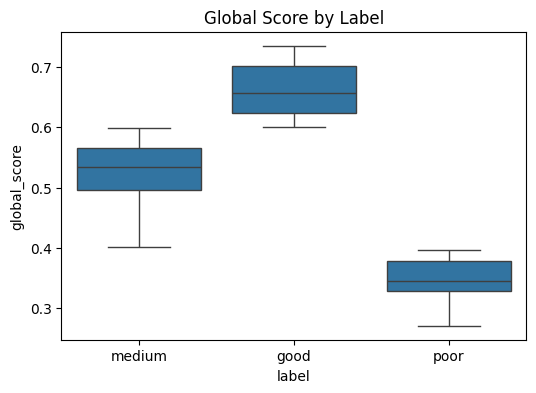


=== GLOBAL SCORE BY LABEL ===
        count      mean       std       min       25%       50%       75%  \
label                                                                       
good     91.0  0.661657  0.041602  0.600479  0.623898  0.656908  0.702241   
medium  137.0  0.531015  0.043871  0.401977  0.495401  0.534718  0.565888   
poor     22.0  0.348957  0.031739  0.270775  0.328868  0.344416  0.377723   

             max  
label             
good    0.735372  
medium  0.598768  
poor    0.396539  

=== POSSIBLE ISSUES ===
High score + high hallucination: 0 cases
Low score + high relevance: 0 cases

=== INTRA-ARTICLE VARIANCE ===
count    50.000000
mean      0.095445
std       0.035693
min       0.016167
25%       0.073289
50%       0.098120
75%       0.121688
max       0.160269
Name: global_score, dtype: float64


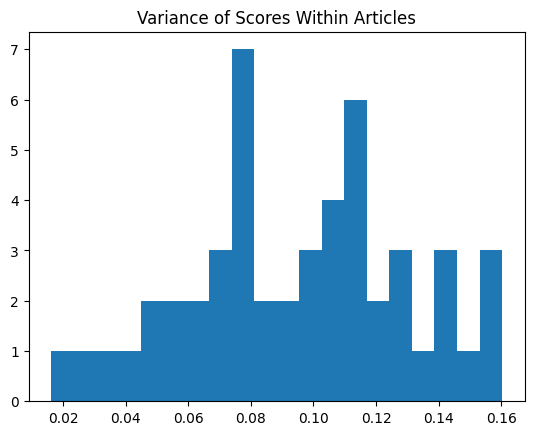

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your data
df = pd.DataFrame(merged)

print("=== BASIC INFO ===")
print(df.shape)
print(df.columns)
print()

# -------------------------
# 1. Score distributions
# -------------------------
score_cols = [
    "relevance", "hallucination", "salience",
    "compression_score", "truncation", "global_score"
]

df[score_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle("Score Distributions")
plt.show()

# -------------------------
# 2. Correlations (internal consistency)
# -------------------------
plt.figure(figsize=(8,6))
corr = df[score_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Score Correlation Matrix")
plt.show()

print("\n=== CORRELATIONS WITH GLOBAL SCORE ===")
print(corr["global_score"].sort_values(ascending=False))

# -------------------------
# 3. Directional sanity checks
# -------------------------
print("\n=== EXPECTED BEHAVIOR CHECK ===")
print("Hallucination vs Global (should be NEGATIVE):", corr.loc["hallucination", "global_score"])
print("Relevance vs Global (should be POSITIVE):", corr.loc["relevance", "global_score"])
print("Salience vs Global (should be POSITIVE):", corr.loc["salience", "global_score"])

# -------------------------
# 4. Separation by label
# -------------------------
if "label" in df.columns:
    print("\n=== LABEL DISTRIBUTION ===")
    print(df["label"].value_counts())

    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="label", y="global_score")
    plt.title("Global Score by Label")
    plt.show()

    # Summary stats per label
    print("\n=== GLOBAL SCORE BY LABEL ===")
    print(df.groupby("label")["global_score"].describe())

# -------------------------
# 5. Outliers / suspicious cases
# -------------------------
print("\n=== POSSIBLE ISSUES ===")

# High score but high hallucination
bad_cases = df[(df["global_score"] > 0.7) & (df["hallucination"] > 0.1)]
print(f"High score + high hallucination: {len(bad_cases)} cases")

# Low score but high relevance
weird_cases = df[(df["global_score"] < 0.3) & (df["relevance"] > 0.8)]
print(f"Low score + high relevance: {len(weird_cases)} cases")


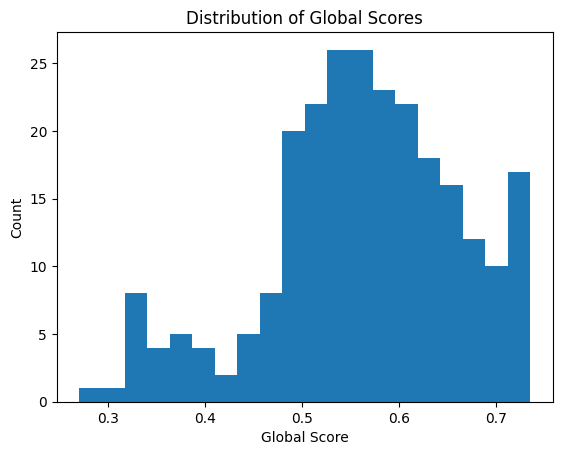

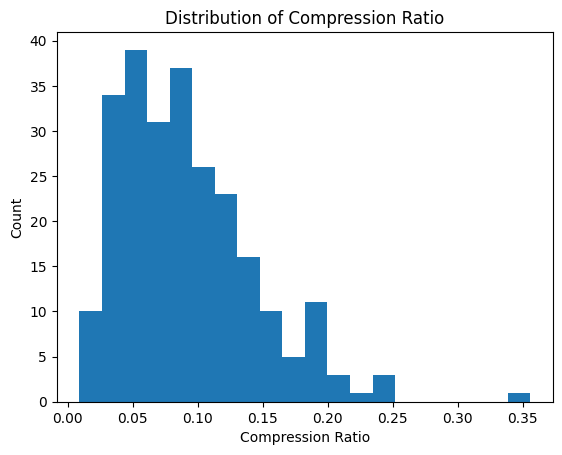

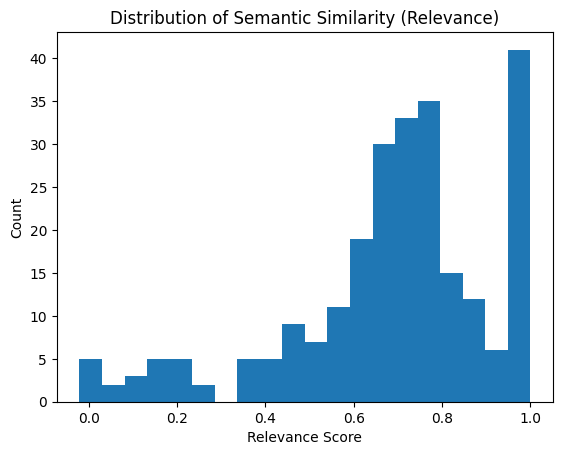

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.DataFrame(merged)

# -------------------------
# Distribution: Global Score
# -------------------------
plt.figure()
plt.hist(df["global_score"], bins=20)
plt.title("Distribution of Global Scores")
plt.xlabel("Global Score")
plt.ylabel("Count")
plt.show()

# -------------------------
# Distribution: Compression Ratio
# -------------------------
if "compression_ratio" in df.columns:
    plt.figure()
    plt.hist(df["compression_ratio"], bins=20)
    plt.title("Distribution of Compression Ratio")
    plt.xlabel("Compression Ratio")
    plt.ylabel("Count")
    plt.show()

# -------------------------
# Distribution: Similarity (Relevance as proxy)
# -------------------------
# Assuming "relevance" ≈ semantic similarity
if "relevance" in df.columns:
    plt.figure()
    plt.hist(df["relevance"], bins=20)
    plt.title("Distribution of Semantic Similarity (Relevance)")
    plt.xlabel("Relevance Score")
    plt.ylabel("Count")
    plt.show()